In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

df = pd.read_csv('../../../data/processed/telco_customer_churn_clean.csv')

## Montly Charge / Total Charge EDA


## Internet Service

### Montly Charge 

### 1) Is Internet service cause Monly Charge Higher

In [5]:
internet_group_Monthly = df[df["InternetService"] != "No"]["MonthlyCharges"]
phone_only_group_Monthly = df[df["InternetService"] == "No"]["MonthlyCharges"]
both_group_Monthly = df[(df["InternetService"] != "No") & (df["PhoneService"] == "Yes")]["MonthlyCharges"]

print("Internet Mean:", internet_group_Monthly.mean())
print("Phone Only Mean:", phone_only_group_Monthly.mean())
print("Both Mean:", both_group_Monthly.mean())

Internet Mean: 76.84425412361792
Phone Only Mean: 21.079193971166447
Both Mean: 81.75517063081698


C:\Users\PoomPT\AppData\Local\Temp\ipykernel_25260\2240622843.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0, 0.5, 'Monthly Charges')

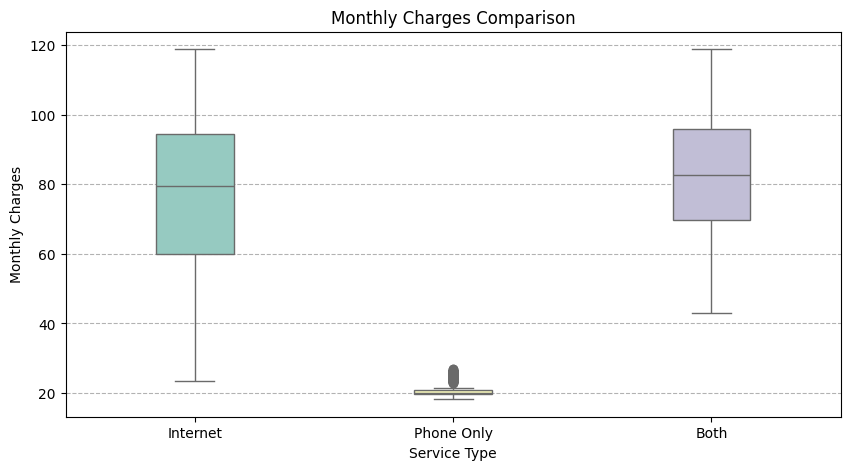

In [25]:
plt.figure(figsize=(10, 5))

data = pd.DataFrame({
    "MonthlyCharges": (
        list(internet_group_Monthly) +
        list(phone_only_group_Monthly) +
        list(both_group_Monthly)
    ),
    "ServiceType": (
        ["Internet"] * len(internet_group_Monthly) +
        ["Phone Only"] * len(phone_only_group_Monthly) +
        ["Both"] * len(both_group_Monthly)
    )
})

sns.boxplot(
    x="ServiceType",
    y="MonthlyCharges",
    data=data,
    width=0.3,
    palette="Set3"
)
plt.grid(axis="y", linestyle="--", alpha=0.3, color='black')
plt.title("Monthly Charges Comparison")
plt.xlabel("Service Type")
plt.ylabel("Monthly Charges")

### Is it relate to churn rate

In [7]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [8]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [9]:
yes = df[df["Churn"] == "Yes"]["MonthlyCharges"]
no = df[df["Churn"] == "No"]["MonthlyCharges"]

t_stat, p_value = ttest_ind(yes, no)
print(p_value)

2.706645606888385e-60


dataset นี้ คนที่จ่ายแพงมี churn rate สูงกว่าโดยเฉลี่ย

ค่า p-value เกณฑ์ทั่วไปคือ:
- p < 0.05 → มีนัยสำคัญ
- mp < 0.01 → มีนัยสำคัญมาก
- p < 0.001 → มีนัยสำคัญมาก ๆ

ค้าของเรา = 10⁻⁶⁰  
++นี่คือ มีนัยสำคัญสูงมาก

Customers who churn pay significantly higher Monthly Charges (Mean = 74.44) compared to retained customers (Mean = 61.27), with a statistically significant difference (p < 0.001). This suggests pricing level may be associated with churn behavior.

### Total Charge 

### 1) Is Internet service cause Total Charge Higher

need to drop Nan Value for TotalCharger

In [10]:
#Dorp NaN values for TotalCharges
internet_group_Total = df[df["InternetService"] != "No"]["TotalCharges"].dropna()
phone_only_group_Total = df[df["InternetService"] == "No"]["TotalCharges"].dropna()
both_group_Total = df[(df["InternetService"] != "No") & (df["PhoneService"] == "Yes")]["TotalCharges"].dropna()

print("Internet Mean:", internet_group_Total.mean())
print("Phone Only Mean:", phone_only_group_Total.mean())
print("Both Mean:", both_group_Total.mean())

Internet Mean: 2729.505406386067
Phone Only Mean: 665.2203289473683
Both Mean: 2902.4707884933773


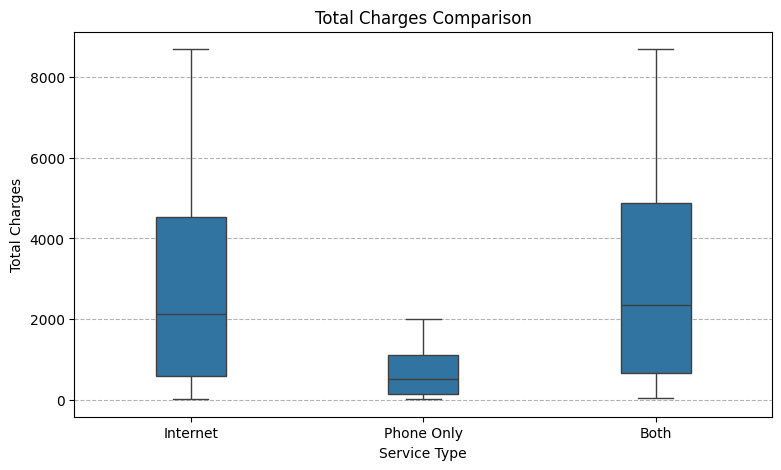

In [33]:
plt.figure(figsize=(9,5))

data = pd.DataFrame({
    "TotalCharges": (
        list(internet_group_Total) +
        list(phone_only_group_Total) +
        list(both_group_Total)
    ),
    "ServiceType": (
        ["Internet"] * len(internet_group_Total) +
        ["Phone Only"] * len(phone_only_group_Total) +
        ["Both"] * len(both_group_Total)
    )
})
sns.boxplot(
    x="ServiceType",
    y="TotalCharges",
    data=data,
    width=0.3,
)

plt.grid(axis="y", linestyle="--", alpha=0.3, color='black')
plt.title("Total Charges Comparison")
plt.xlabel("Service Type")
plt.ylabel("Total Charges")

plt.show()

ความเกี่ยวข้อง TotalCharge ต่อ Churn

In [12]:
yes = df[df["Churn"] == "Yes"]["TotalCharges"].dropna()
no = df[df["Churn"] == "No"]["TotalCharges"].dropna()

t_stat, p_value = ttest_ind(yes, no)
print(p_value)

4.8768656896944645e-64


#### สรุปความเกี่ยวข้อง TotalCharge, MontlyCharge ต่อ Internet Service 

In [13]:
df[["MonthlyCharges", "TotalCharges", "tenure"]].corr()

,MonthlyCharges,TotalCharges,tenure
MonthlyCharges,1.000000,0.651065,0.24790
TotalCharges,0.651065,1.000000,0.82588
tenure,0.247900,0.825880,1.00000


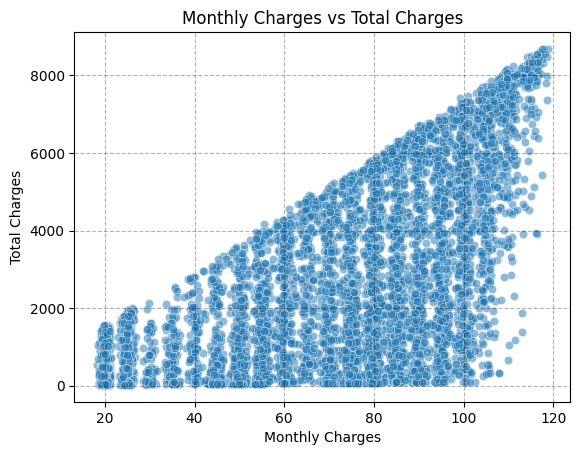

In [34]:
sns.scatterplot(x=df["MonthlyCharges"], y=df["TotalCharges"], alpha=0.5)
plt.title("Monthly Charges vs Total Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.grid(linestyle="--", alpha=0.3, color='black')
plt.show()

In [14]:
df.groupby("Churn")["TotalCharges"].mean()

Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64

In [15]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [16]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

total charge มีผล

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

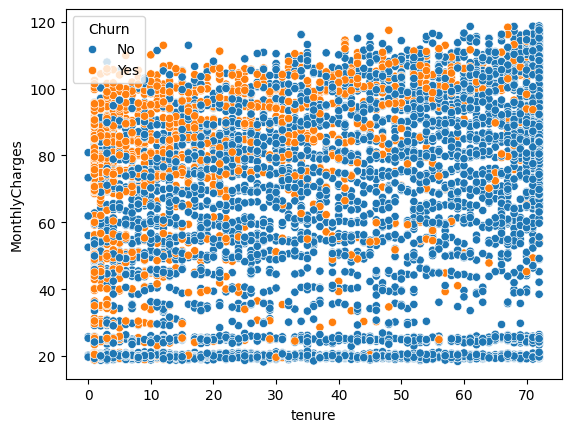

In [18]:
sns.scatterplot(
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    data=df
)

- จะเห็นได้ว่า Internet Service มีผลต่อ การเพิ่มขึ้นของ MontlyCharge(ค่าไช้จ่ายต่อเดือน) และ มีผลต่อ TotalCharge และยิ่ง ไช้ทั้งบริการ PhoneService ยิ่งส่งผลไห้ ราคาเพิ่มขึ้นกว่าเดิม

(มุมมองสอดคล้อง)
- เพราะ ตามความน่าจะเป็นมันหมายถึงว่า ลูกค้า เสียค่าไช้จ่ายต่อเดือนแพง ทําไห้ มี อายุการไช้งานตํ่า เมื่อเทียบกับ ลูกค้าเสียค่าไช้จ่ายต่อเดือนน้อย ทําไห้ มีtenure(อายุการไช้งานยาวนานกว่า) ทําไห้ ผมรวมค่าไช้จ่ายตั้งแต่ต้นจนถึงปัจจุบัน(TotalCharge) มี่ค่ามากกว่า

** insight
MontlyCharge สูง & Tenure ตํ่ามี